<a href="https://colab.research.google.com/github/dilarayardimeden/dsa210-project/blob/main/optimal_movie_runtime_analysis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Is There an Optimal Movie Runtime for Higher Audience Ratings?
### DSA 210 — Spring 2026 Term Project
**Author:** Dilara Yardımeden  
**Dataset:** TMDb 5000 Movies Metadata + TMDb 5000 Credits (Kaggle) + Rotten Tomatoes Movies Dataset
---

## Research Question
Does movie runtime affect audience ratings? Is there an optimal duration range that consistently leads to higher scores, and do production-related factors such as cast size provide additional explanatory power?

## Hypothesis

H0: Movie runtime and production-related features have no significant relationship with audience ratings.

H1: Movie runtime has a statistically significant relationship with audience ratings, and production-related features such as cast size may provide additional insight into rating differences.

## Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

## Data Loading

How to obtain the datasets:

1. Download the TMDb datasets from:
https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

Required files:
- tmdb_5000_movies.csv
- tmdb_5000_credits.csv

2. Download the Rotten Tomatoes dataset from:
https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset

Required file:
- rotten_tomatoes_movies.csv

3. Upload all CSV files to the notebook environment before running the analysis.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving rotten_tomatoes_movies.csv to rotten_tomatoes_movies.csv
Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv


---
##  CSV


### Dataset Integration

In order to enrich the analysis, the TMDb movie metadata dataset is combined with the TMDb credits dataset.

The credits dataset provides additional information about cast and crew members.
By merging the two datasets on the movie title, new features such as cast size and director information can be extracted and used in further analysis.

In [3]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")
rotten = pd.read_csv("rotten_tomatoes_movies.csv", sep=";", engine="python", on_bad_lines="skip")
rotten.head()

movies = movies.merge(credits, on="title", how="left")

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Data Cleaning
In this section, missing values are removed and only the relevant variables are kept for the analysis.

### Feature Engineering and Data Preparation

After merging the two datasets, additional features were extracted from the credits dataset.

- The **director** of each movie was identified from the crew information.
- The **cast size** was computed by counting the number of actors listed.

These features allow the analysis to go beyond runtime and include production-related characteristics that may influence audience ratings.

In addition, missing values were handled and only relevant variables were retained for the analysis.

In [4]:
import ast

def get_director(crew):
    try:
        crew_list = ast.literal_eval(crew)
        for person in crew_list:
            if person.get("job") == "Director":
                return person.get("name")
        return None
    except Exception:
        return None

def get_cast_size(cast):
    try:
        cast_list = ast.literal_eval(cast)
        return len(cast_list)
    except Exception:
        return 0

movies["director"] = movies["crew"].apply(get_director)
movies["cast_size"] = movies["cast"].apply(get_cast_size)

movies["director"] = movies["director"].fillna("Unknown")

movies = movies[['title', 'runtime', 'vote_average', 'vote_count', 'director', 'cast_size']]

movies = movies.dropna(subset=['runtime', 'vote_average'])
movies = movies[(movies['runtime'] >= 40) & (movies['runtime'] <= 300)]
movies = movies[movies['vote_count'] >= 20]

movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4139 entries, 0 to 4804
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         4139 non-null   object 
 1   runtime       4139 non-null   float64
 2   vote_average  4139 non-null   float64
 3   vote_count    4139 non-null   int64  
 4   director      4139 non-null   object 
 5   cast_size     4139 non-null   int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 226.4+ KB


After cleaning, the dataset keeps movies with valid runtime and rating values.

Very short movies, extremely long movies, and movies with very low vote counts were removed to reduce noise and make the rating comparison more reliable.

## External Rotten Tomatoes Dataset Enrichment

To further strengthen the enrichment part of the project, an external Rotten Tomatoes movie dataset was incorporated into the analysis.

Unlike the TMDb credits dataset, this dataset comes from a different movie rating platform and provides additional audience and critic-based rating metrics.

The datasets were merged using movie titles, allowing the comparison of TMDb ratings with Rotten Tomatoes audience and tomatometer scores.

This external validation helps evaluate whether the observed relationship between movie runtime and ratings remains consistent across different rating platforms.

This step was added especially to address the dataset enrichment requirement and to avoid relying only on variables from the same TMDb Kaggle package.

In [5]:
rotten_external = rotten[[
    "movie_title",
    "runtime",
    "tomatometer_rating",
    "tomatometer_count",
    "audience_rating",
    "audience_count"
]].copy()


rotten_external = rotten_external.rename(columns={
    "movie_title": "rt_title",
    "runtime": "rt_runtime",
    "tomatometer_rating": "rt_tomatometer_rating",
    "tomatometer_count": "rt_tomatometer_count",
    "audience_rating": "rt_audience_rating",
    "audience_count": "rt_audience_count"
})


movies["title_clean"] = movies["title"].str.strip().str.lower()
rotten_external["title_clean"] = rotten_external["rt_title"].str.strip().str.lower()


movies = movies.merge(rotten_external, on="title_clean", how="left")

print("Matched movies with Rotten Tomatoes:", movies["rt_audience_rating"].notna().sum())
print("Total movies:", len(movies))

movies[[
    "title",
    "runtime",
    "vote_average",
    "rt_tomatometer_rating",
    "rt_audience_rating"
]].head()

Matched movies with Rotten Tomatoes: 3905
Total movies: 4431


,title,runtime,vote_average,rt_tomatometer_rating,rt_audience_rating
0,Avatar,162.0,7.2,82.0,82.0
1,Pirates of the Caribbean: At World's End,169.0,6.9,NaN,NaN
2,Spectre,148.0,6.3,63.0,61.0
3,The Dark Knight Rises,165.0,7.6,87.0,90.0
4,John Carter,132.0,6.1,52.0,60.0


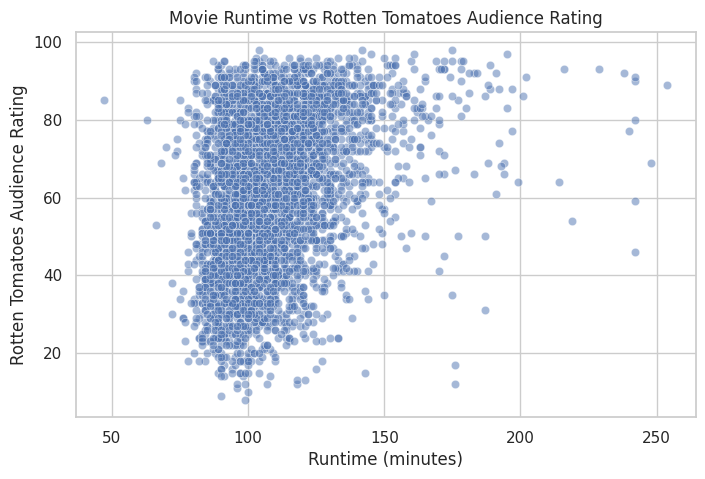

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=movies,
    x="runtime",
    y="rt_audience_rating",
    alpha=0.5
)

plt.title("Movie Runtime vs Rotten Tomatoes Audience Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Rotten Tomatoes Audience Rating")

plt.show()

The relationship between runtime and audience ratings was also examined using Rotten Tomatoes audience scores. Similar to the TMDb results, movies within moderate-to-long runtime ranges generally tend to receive relatively higher audience ratings, although the relationship is not perfectly linear.

In [7]:
correlation = movies[[
    "vote_average",
    "rt_audience_rating"
]].corr()

print(correlation)

                    vote_average  rt_audience_rating
vote_average            1.000000            0.811087
rt_audience_rating      0.811087            1.000000


The correlation between TMDb vote averages and Rotten Tomatoes audience ratings is strongly positive.

This suggests that although the two platforms use different rating systems, audience evaluation patterns are broadly consistent.

Therefore, Rotten Tomatoes can be used as an external validation source for the runtime-rating analysis.

## Exploratory Data Analysis
This section explores the relationship between movie runtime and audience ratings using visualizations and summary statistics.

Additionally, the analysis considers whether longer movies tend to receive higher ratings and whether any clear patterns or trends emerge from the data.

### Scatter Plot

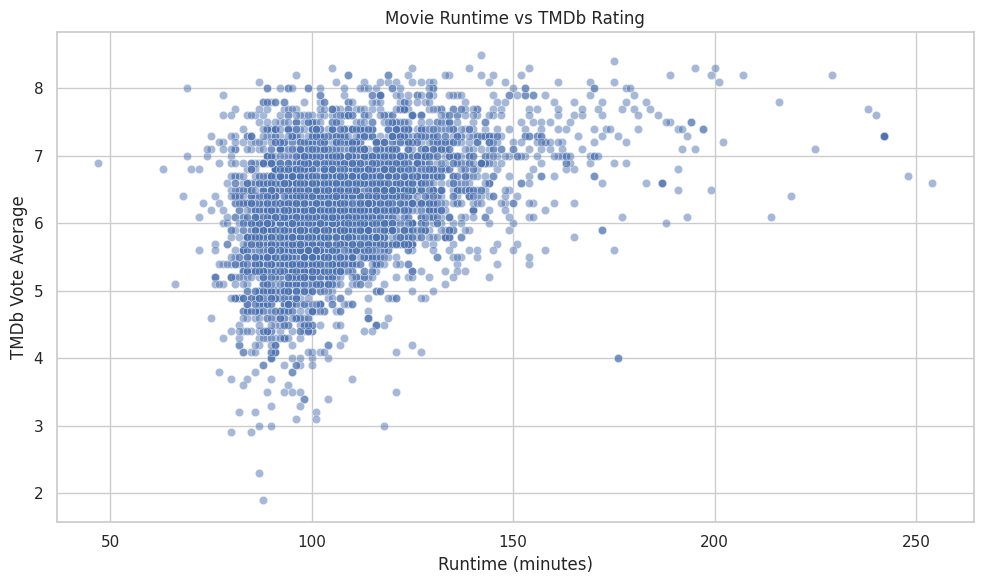

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=movies, x='runtime', y='vote_average', alpha=0.5)

plt.title("Movie Runtime vs TMDb Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("TMDb Vote Average")

plt.tight_layout()
plt.savefig("fig02_scatter_runtime_rating.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
correlation = movies[[
    "vote_average",
    "rt_audience_rating"
]].corr()

print(correlation)

                    vote_average  rt_audience_rating
vote_average            1.000000            0.811087
rt_audience_rating      0.811087            1.000000


The correlation between TMDb ratings and Rotten Tomatoes audience ratings is relatively strong, with a correlation coefficient of approximately 0.81.

This suggests that audience evaluation patterns are generally consistent across the two different movie rating platforms.

Although the platforms use different rating systems, movies that receive higher ratings on TMDb also tend to receive higher audience ratings on Rotten Tomatoes.

### Correlation

In [10]:
corr = movies[['runtime', 'vote_average']].corr()
print(corr)

               runtime  vote_average
runtime       1.000000      0.394028
vote_average  0.394028      1.000000


The correlation between runtime and vote average is approximately 0.40, indicating a moderate positive relationship.

This suggests that longer movies tend to receive higher ratings on average, although the relationship is not strong enough to be considered highly predictive.

### Runtime Bucket



In [11]:
movies['runtime_bucket'] = pd.cut(
    movies['runtime'],
    bins=[0, 80, 100, 120, 140, 160, 300],
    labels=['40-80', '81-100', '101-120', '121-140', '141-160', '160+']
)

bucket_means = movies.groupby('runtime_bucket', observed=True)['vote_average'].mean()
print(bucket_means)

runtime_bucket
40-80      6.030769
81-100     5.910623
101-120    6.312872
121-140    6.667978
141-160    6.987151
160+       7.194643
Name: vote_average, dtype: float64


The average ratings increase as runtime increases across most runtime buckets.

Movies shorter than 100 minutes tend to have lower average ratings, while ratings steadily improve for movies in the 100–160 minute range.

The highest average rating is observed for movies longer than 160 minutes. However, this group likely contains fewer observations, so the result should be interpreted with caution.

Overall, these results suggest that longer movies tend to receive higher ratings, and the optimal runtime range appears to be around 120–160 minutes where ratings are consistently high.

###Bar Chart

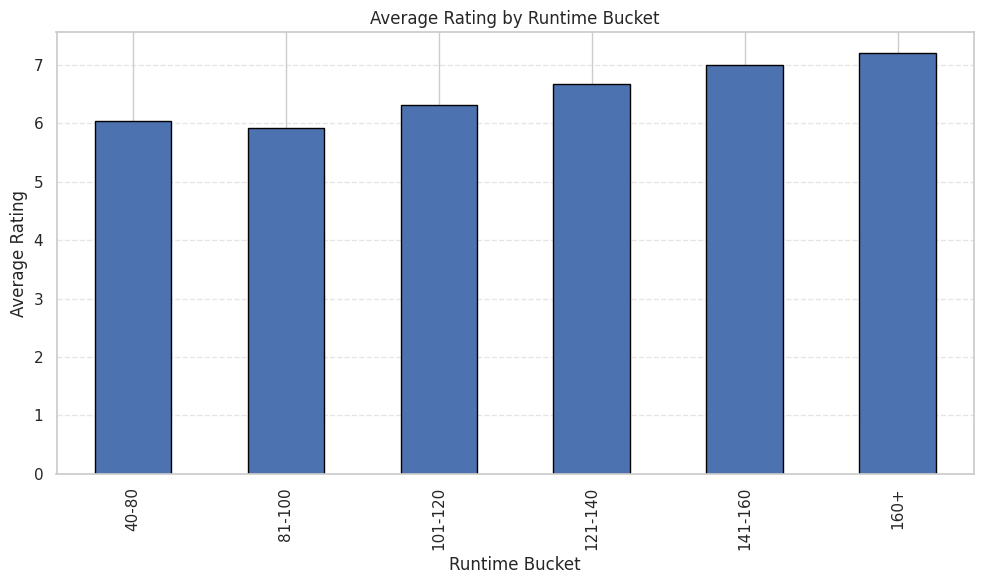

In [12]:
plt.figure(figsize=(10,6))
bucket_means.plot(kind='bar', edgecolor='black')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.title("Average Rating by Runtime Bucket")
plt.xlabel("Runtime Bucket")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.savefig("fig03_bar_bucket_ratings.png", dpi=300, bbox_inches="tight")
plt.show()

The bar chart shows that average ratings generally increase as runtime increases, although the trend is not perfectly linear.

Movies in the 81–100 minute range have slightly lower ratings compared to shorter films, but ratings begin to rise steadily after 100 minutes.

This suggests that longer movies, particularly those above 100 minutes, tend to receive higher audience ratings, possibly due to more developed storytelling and character depth.

###Boxplot

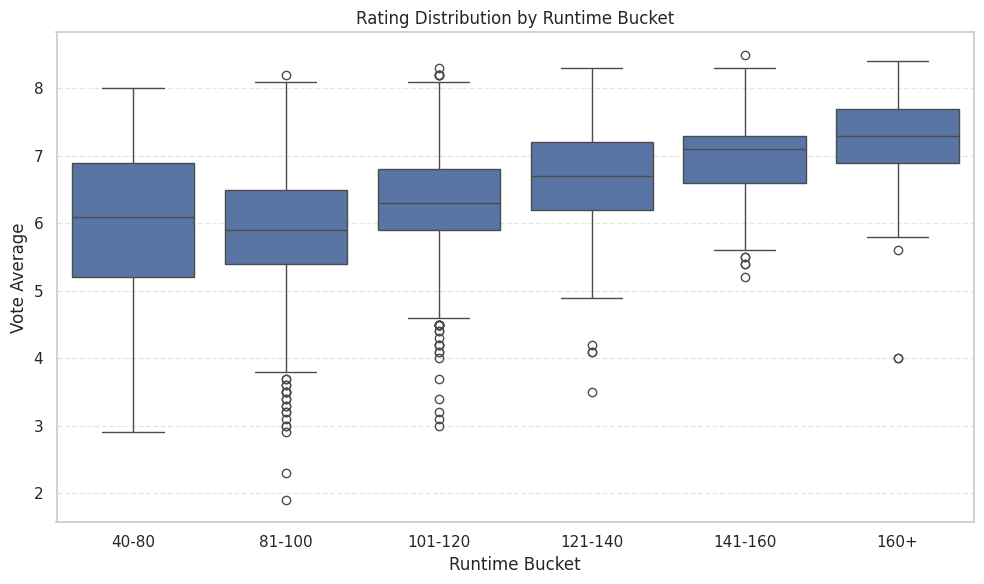

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(data=movies, x='runtime_bucket', y='vote_average')

plt.title("Rating Distribution by Runtime Bucket")
plt.xlabel("Runtime Bucket")
plt.ylabel("Vote Average")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("fig04_boxplot_buckets.png", dpi=300, bbox_inches='tight')
plt.show()

The boxplot shows that median ratings tend to increase as runtime increases, indicating that longer movies generally receive higher ratings.

However, the spread of ratings remains relatively wide across most runtime categories, suggesting that variability is still present and runtime alone does not fully explain rating differences.

Notably, movies longer than 120 minutes show higher median values, suggesting that moderate-to-long runtimes are associated with relatively higher audience ratings.

### Enrichment Feature: Cast Size vs Rating

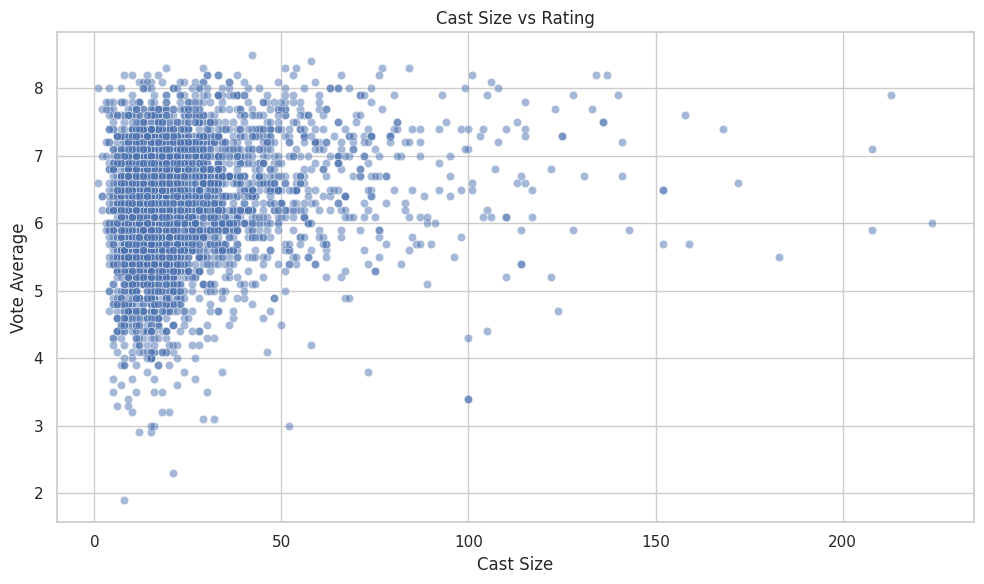

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=movies, x='cast_size', y='vote_average', alpha=0.5)

plt.title("Cast Size vs Rating")
plt.xlabel("Cast Size")
plt.ylabel("Vote Average")

plt.tight_layout()
plt.savefig("fig07_cast_size_rating.png", dpi=300, bbox_inches="tight")
plt.show()

The scatter plot shows that there is no clear strong relationship between cast size and audience ratings.

While movies with larger casts may occasionally receive higher ratings, the data points are widely dispersed, indicating that cast size alone is not a strong predictor of rating outcomes.

This suggests that other factors, such as storytelling, genre, or production quality, likely play a more significant role in determining audience ratings.

## Hypothesis Testing
This section applies multiple hypothesis tests to evaluate whether movie runtime and enriched production-related features are statistically associated with audience ratings.

The ANOVA test examines rating differences across runtime groups, the Pearson correlation test evaluates the linear relationship between runtime and rating, and the t-test compares ratings between movies with high and low cast sizes.

### ANOVA

In [15]:
# Prepare groups for ANOVA
groups = [
    group['vote_average'].values
    for name, group in movies.groupby('runtime_bucket', observed=True)
]

# Perform ANOVA test
from scipy import stats

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_value)

ANOVA F-statistic: 169.1491308924876
p-value: 4.414045337171086e-165


The ANOVA test results show a very large F-statistic (≈169.15) and an extremely small p-value (≈0), indicating strong statistical evidence that average ratings differ across runtime groups.

This means that movie runtime has a statistically significant effect on audience ratings. The differences observed between runtime categories are unlikely to be due to random variation.

However, while the effect is statistically significant, it does not necessarily imply a strong practical effect. As seen in earlier visualizations, the variability within groups remains high, suggesting that runtime alone does not fully explain rating differences.

### Pearson Correlation Test

In [16]:
corr, p_value = stats.pearsonr(movies['runtime'], movies['vote_average'])

print("Pearson correlation:", corr)
print("p-value:", p_value)

Pearson correlation: 0.39402750462264347
p-value: 1.6351857306027206e-164


The Pearson correlation test shows whether there is a statistically significant linear relationship between runtime and audience rating.

The result indicates a positive relationship between runtime and rating. Since the p-value is below 0.05, this relationship is statistically significant. However, the correlation is moderate rather than strong, meaning runtime is related to ratings but does not fully explain them on its own.

### T-Test: High Cast Size vs Low Cast Size

In [17]:
# Create two groups based on median cast size
movies['cast_group'] = np.where(
    movies['cast_size'] >= movies['cast_size'].median(),
    'High Cast Size',
    'Low Cast Size'
)

high_cast = movies[movies['cast_group'] == 'High Cast Size']['vote_average']
low_cast = movies[movies['cast_group'] == 'Low Cast Size']['vote_average']

# Independent t-test
t_stat, p_value = stats.ttest_ind(high_cast, low_cast, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_value)

T-statistic: 10.542691786723699
p-value: 1.1092373309536203e-25


This t-test compares the average ratings of movies with larger casts and smaller casts.

This test was added because cast size was derived from the enriched credits dataset. Since the p-value is far below 0.05, the results suggest a statistically significant difference between movies with high and low cast sizes. Movies with larger casts tend to receive slightly higher average ratings on average.

However, even if the result is statistically significant, cast size should be interpreted carefully because a larger cast does not automatically mean a better movie. It is only one production-related factor among many others.

## Regression Analysis
This section uses regression models to examine whether movie runtime can explain variation in audience ratings. The first model uses only runtime as a predictor, allowing us to evaluate its individual relationship with ratings.

###  Simple Linear Regression


In [18]:
X = movies[['runtime']]
y = movies['vote_average']

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)
r2 = r2_score(y, y_pred)

print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_[0])
print("R^2:", r2)
print(f"Model: vote_average = {lr.intercept_:.4f} + {lr.coef_[0]:.4f} * runtime")

Intercept: 4.475150782495746
Slope: 0.016364191612326086
R^2: 0.1552576743991474
Model: vote_average = 4.4752 + 0.0164 * runtime


The linear regression model estimates the relationship between movie runtime and audience ratings.

The slope coefficient (~0.017) indicates that for each additional minute of runtime, the average rating increases slightly. This suggests a positive relationship between runtime and ratings.

However, the R² value (~0.155) is relatively low is relatively low, meaning that runtime explains only about 15% of the variation of the variation in audience ratings. This indicates that while runtime has a measurable effect, it is not a strong predictor on its own.

The intercept (~4.40) represents the baseline rating when runtime is zero, which is not meaningful in practice but is part of the model structure.

Overall, the model confirms that longer movies tend to receive slightly higher ratings, but many other factors such as genre, storytelling quality, or production-related features likely play a more significant role.

###  Multiple Linear Regression with Enriched Features

In [19]:
# Multiple Linear Regression with enriched features

X_multi = movies[['runtime', 'cast_size']]
y = movies['vote_average']

lr_multi = LinearRegression()
lr_multi.fit(X_multi, y)

y_pred_multi = lr_multi.predict(X_multi)
r2_multi = r2_score(y, y_pred_multi)

print("Intercept:", lr_multi.intercept_)
print("Coefficients:", dict(zip(X_multi.columns, lr_multi.coef_)))
print("R^2:", r2_multi)

Intercept: 4.498873698763026
Coefficients: {'runtime': np.float64(0.01535398687669882), 'cast_size': np.float64(0.0035887398115348927)}
R^2: 0.16172441057226972


This model extends the simple linear regression by including cast size, which was created from the enriched credits dataset.

By adding cast size, the model evaluates whether production-related information provides additional explanatory power beyond runtime alone.

The coefficients show the estimated effect of each variable while holding the other variable constant. If the runtime coefficient remains positive, this suggests that the relationship between runtime and rating is not only due to cast size.

The R² value can be compared with the simple linear regression model. If it increases, this means that the enriched feature improves the model’s ability to explain variation in audience ratings.

Overall, this model better reflects the project feedback by using the second dataset not only for EDA, but also as part of the regression analysis.

###Polynomial Regression

In [20]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

x_range = pd.DataFrame(np.linspace(40, 300, 1000), columns=['runtime'])
x_range_poly = poly.transform(x_range)
y_pred_range = poly_model.predict(x_range_poly)

optimal_runtime = x_range.iloc[np.argmax(y_pred_range), 0]
print(f"Optimal runtime (polynomial model): {optimal_runtime:.1f} minutes")

Optimal runtime (polynomial model): 223.7 minutes


###Polynomial Regresion Graphic

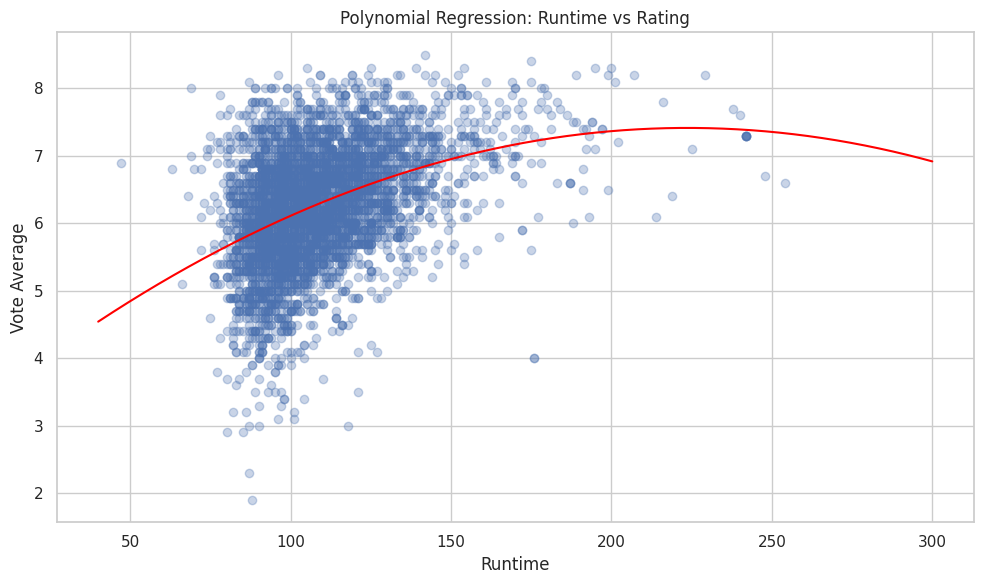

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(X, y, alpha=0.3)
plt.plot(x_range, y_pred_range, color='red')

plt.title("Polynomial Regression: Runtime vs Rating")
plt.xlabel("Runtime")
plt.ylabel("Vote Average")

plt.tight_layout()
plt.savefig("fig06_poly_regression.png", dpi=300, bbox_inches="tight")
plt.show()

The polynomial regression model captures a non-linear relationship between runtime and audience ratings, revealing a pattern that cannot be explained by a simple linear model.

Ratings tend to increase as runtime increases up to a certain point, after which the trend stabilizes and slightly declines. This indicates a diminishing return effect, where longer movies do not necessarily lead to higher ratings.

The model suggests a potential peak around 220–230 minutes. However, this should not be interpreted as a definitive optimal runtime.

Therefore, the polynomial peak should be interpreted as a modeled tendency rather than an exact real-world optimal runtime.

Movies with extremely long runtimes are relatively underrepresented in the dataset, and a small number of high-rated outliers may disproportionately influence the curve.

A more reliable insight emerges when considering the density of observations: movies in the 120–160 minute range consistently achieve higher ratings across a larger number of samples. This suggests that moderately long movies strike a better balance between depth and audience engagement.

Overall, the findings indicate that while runtime does influence ratings, its effect is not strictly linear, and extreme values should be interpreted with caution.



### Model Comparison

Both linear and polynomial regression models were used to analyze the relationship between runtime and ratings.

The linear regression model captures a general upward trend, suggesting that ratings tend to increase as runtime increases. However, its relatively low R² value (~0.16) indicates that this relationship is weak and does not fully explain rating variability.

The polynomial regression model captures a non-linear pattern, showing that ratings increase up to a certain point and then stabilize. This provides a more realistic representation of the relationship.

However, both models have limited explanatory power, suggesting that runtime alone is not sufficient to predict movie ratings. Additional features such as genre, budget, and production quality likely play a more important role.

## Machine Learning Analysis

In this section, a machine learning model is used to predict movie ratings using runtime, vote count, and cast size.

Including cast size allows the model to use information extracted from the enriched credits dataset, directly addressing the project feedback about adding a second dataset.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = movies[['runtime', 'vote_count', 'cast_size']]
y = movies['vote_average']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.7546079168313352
R²: 0.24209189968103184


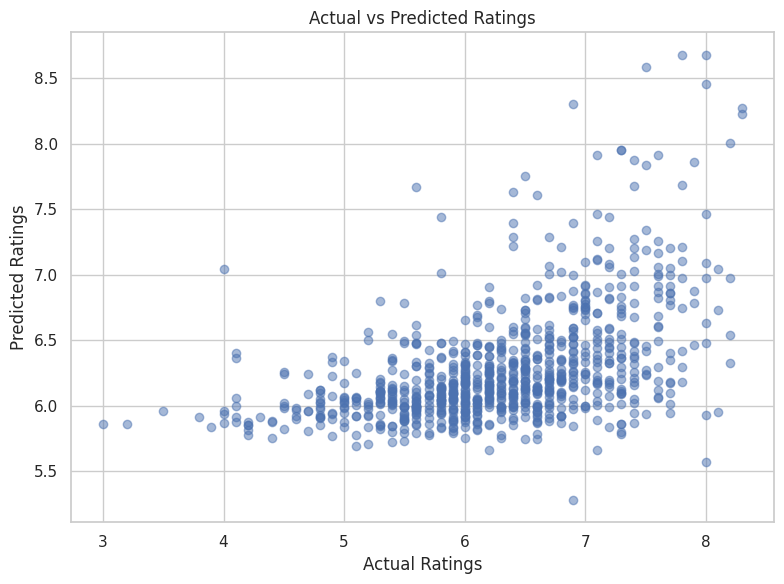

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")

plt.tight_layout()
plt.savefig("fig08_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

The model achieves an R² of approximately 0.24, meaning that runtime, vote count, and cast size together explain about 24% of the variation of the variation in movie ratings.

This indicates that these features provide some predictive signal, but they are not sufficient to fully explain audience ratings. Other factors such as genre, director, budget, storytelling quality, and audience preferences likely account for much of the remaining variation.

The actual vs predicted plot also shows that predictions are clustered around the middle rating range, suggesting that the model has difficulty capturing very low or very high ratings.

Even after incorporating additional features such as vote count and cast size, the model’s performance remains limited. This suggests that movie ratings are influenced by more complex and unobserved factors beyond the variables included in this analysis.

These results indicate that incorporating additional enriched features improves predictive performance compared to simpler regression models, although movie ratings remain difficult to predict due to the subjective nature of audience preferences.

## Conclusion

This analysis examined whether movie runtime has a significant effect on audience ratings using statistical analysis, regression models, and machine learning techniques.

The correlation analysis revealed a moderate positive relationship between runtime and ratings (r ≈ 0.40), suggesting that longer movies tend to receive slightly higher ratings on average. The ANOVA test further indicated that audience ratings differ significantly across runtime groups, confirming that runtime has a statistically significant effect on ratings.

Regression analysis supported these findings by identifying a positive but relatively weak relationship between runtime and ratings. While the linear regression model showed an upward trend, the polynomial regression model revealed a non-linear pattern in which ratings increase up to a certain point before stabilizing. A more reliable pattern emerged in the 120–160 minute range, where movies consistently achieved relatively high ratings across a larger number of observations.

The enriched TMDb credits dataset allowed the project to incorporate additional production-related features such as cast size into both the statistical analysis and machine learning models. Including these variables slightly improved predictive performance, demonstrating the value of using a second dataset beyond basic exploratory analysis.

However, the relatively low R² values across the models indicate that runtime and production-related variables alone cannot fully explain audience ratings. Movie ratings are likely influenced by many additional factors such as genre, storytelling quality, budget, marketing, direction, and individual audience preferences.

Overall, the findings suggest that movie runtime does influence audience ratings, but the relationship is complex, non-linear, and limited in predictive power. Longer movies may benefit from deeper storytelling and character development, yet extremely long runtimes do not necessarily guarantee higher audience ratings.

## Limitations

This analysis is limited by the available variables in the TMDb datasets and does not fully capture important factors such as genre differences, screenplay quality, marketing effects, critic reviews, or detailed director-level influences.

In addition, audience ratings are inherently subjective and may vary across different viewer groups, cultures, and time periods. Some extremely long movies are also underrepresented in the dataset, which may affect the reliability of the polynomial regression results at higher runtime values.

Future studies could incorporate richer external datasets, additional production-related features, and more advanced machine learning methods to improve predictive performance and provide a deeper understanding of audience preferences.

---
*End of Analysis — DSA 210 Spring 2026 Term Project*